In [1]:
import keras
from keras.callbacks import ModelCheckpoint
from keras.utils import to_categorical
import pandas as pd
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt

In [2]:
zip_file_path = '/content/dataset.zip'
extract_dir = 'louisiana_images'

In [3]:
train_df = pd.read_csv(extract_dir + '/train.csv')
test_df = pd.read_csv(extract_dir + '/test.csv')

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import tensorflow as tf
import os

image_size = (512, 360)
batch_size = 32

def preprocess_image_py(image_path_tensor, label):
    image_path = image_path_tensor.numpy().decode('utf-8')
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_image(img, channels=3)
        if img.shape.rank == 0:  # Verifica se a imagem está vazia
            raise ValueError(f"imagem vazia")
        img = tf.image.resize(img, image_size)
        img = tf.cast(img, tf.float32) / 255.0  # Normaliza para o intervalo [0, 1]
        return img, label
    except Exception as e:
        print(f"Erro ao processar a imagem {image_path}: {e}")
        # Retorna uma imagem preta preenchida com zeros como substituta
        return tf.zeros((*image_size, 3), dtype=tf.float32), label

def preprocess_image(image_path, label):
    processed_image, processed_label = tf.py_function(
        preprocess_image_py,
        inp=[image_path, label],
        Tout=[tf.float32, label.dtype]
    )
    processed_image.set_shape([*image_size, 3])
    processed_label.set_shape([])
    return processed_image, processed_label

# --- Criar Dataset de Treino ---
print("Criando dataset de treino...")
train_image_filenames = train_df['Image ID'].values
train_labels = train_df['Flooded'].values

train_image_paths = [os.path.join(extract_dir, 'train', fname) for fname in train_image_filenames]

train_dataset = tf.data.Dataset.from_tensor_slices((train_image_paths, train_labels))

train_dataset = train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(buffer_size=len(train_image_paths)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# --- Criar Dataset de Teste ---
print("Criando dataset de teste...")
test_image_filenames = test_df['Image ID'].values
test_labels = test_df['Flooded'].values

test_image_paths = [os.path.join(extract_dir, 'test', fname) for fname in test_image_filenames]

test_dataset = tf.data.Dataset.from_tensor_slices((test_image_paths, test_labels))
test_dataset = test_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE) # Não embaralha o conjunto de teste

print("Datasets de treino e teste criados com sucesso.")
print(f"Número de amostras de treino: {len(train_image_paths)}")
print(f"Número de amostras de teste: {len(test_image_paths)}")

# Opcional: Verificar um batch do dataset de treino
for images, labels in train_dataset.take(1):
    print(f"Formato do batch de imagens de treino: {images.shape}")
    print(f"Formato do batch de labels de treino: {labels.shape}")
    print(f"Tipo de dados do batch de imagens de treino: {images.dtype}")
    print(f"Tipo de dados do batch de labels de treino: {labels.dtype}")
    break


Criando dataset de treino...
Criando dataset de teste...
Datasets de treino e teste criados com sucesso.
Número de amostras de treino: 270
Número de amostras de teste: 52
Formato do batch de imagens de treino: (32, 512, 360, 3)
Formato do batch de labels de treino: (32,)
Tipo de dados do batch de imagens de treino: <dtype: 'float32'>
Tipo de dados do batch de labels de treino: <dtype: 'int64'>


In [6]:
from keras.applications import EfficientNetB4
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from keras.optimizers import Adam

# Definindo o formato de entrada explicitamente com base no pré-processamento
input_shape = (512, 360, 3)

print("Carregando o modelo EfficientNetB4 com pesos imagenet...")
base_model = EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=input_shape
)

print("Modelo base EfficientNetB4 carregado com sucesso.")

# Congelar as camadas do modelo base para não serem treinadas
base_model.trainable = False
print("Camadas do modelo base congeladas.")

# Adiciona camadas para classificação binária
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x) # Camada para reduzir overfitting

output_layer = Dense(1, activation='sigmoid')(x)

# Cria o modelo final
model = Model(inputs=base_model.input, outputs=output_layer)

# Compila o modelo
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Exibe o resumo do modelo
model.summary()

print("Modelo de Transfer Learning criado e compilado com sucesso!")

Carregando o modelo EfficientNetB4 com pesos imagenet...
Modelo base EfficientNetB4 carregado com sucesso.
Camadas do modelo base congeladas.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 360,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 512, 360,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 512, 360,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 512, 360,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 513, 361,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 256, 180,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 256, 180,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 256, 180,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 256, 180,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 256, 180,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 256, 180,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 256, 180,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 256, 180,  │      1,152 │ block1a_se_excit

 Total params: 17,675,616 (67.43 MB)

 Trainable params: 1,793 (7.00 KB)

 Non-trainable params: 17,673,823 (67.42 MB)

Modelo de Transfer Learning criado e compilado com sucesso!


In [7]:
# cria um checkpoint para salvar os pesos do melhor modelo encontrado no treinamento
checkpointer = ModelCheckpoint(filepath='model.weights.best.keras', verbose=1, save_best_only=True)

# treina o modelo
hist = model.fit(train_dataset, epochs=50,
          validation_data=test_dataset,
          callbacks=[checkpointer],
          verbose=2)

Epoch 1/50

Epoch 1: val_loss improved from None to 0.62169, saving model to model.weights.best.keras

Epoch 1: finished saving model to model.weights.best.keras
9/9 - 161s - 18s/step - accuracy: 0.6815 - loss: 0.6359 - val_accuracy: 0.6923 - val_loss: 0.6217
Epoch 2/50

Epoch 2: val_loss improved from 0.62169 to 0.61804, saving model to model.weights.best.keras

Epoch 2: finished saving model to model.weights.best.keras
9/9 - 7s - 830ms/step - accuracy: 0.6815 - loss: 0.6333 - val_accuracy: 0.6923 - val_loss: 0.6180
Epoch 3/50

Epoch 3: val_loss improved from 0.61804 to 0.61734, saving model to model.weights.best.keras

Epoch 3: finished saving model to model.weights.best.keras
9/9 - 8s - 843ms/step - accuracy: 0.6815 - loss: 0.6273 - val_accuracy: 0.6923 - val_loss: 0.6173
Epoch 4/50

Epoch 4: val_loss improved from 0.61734 to 0.61726, saving model to model.weights.best.keras

Epoch 4: finished saving model to model.weights.best.keras
9/9 - 7s - 792ms/step - accuracy: 0.6815 - loss: 

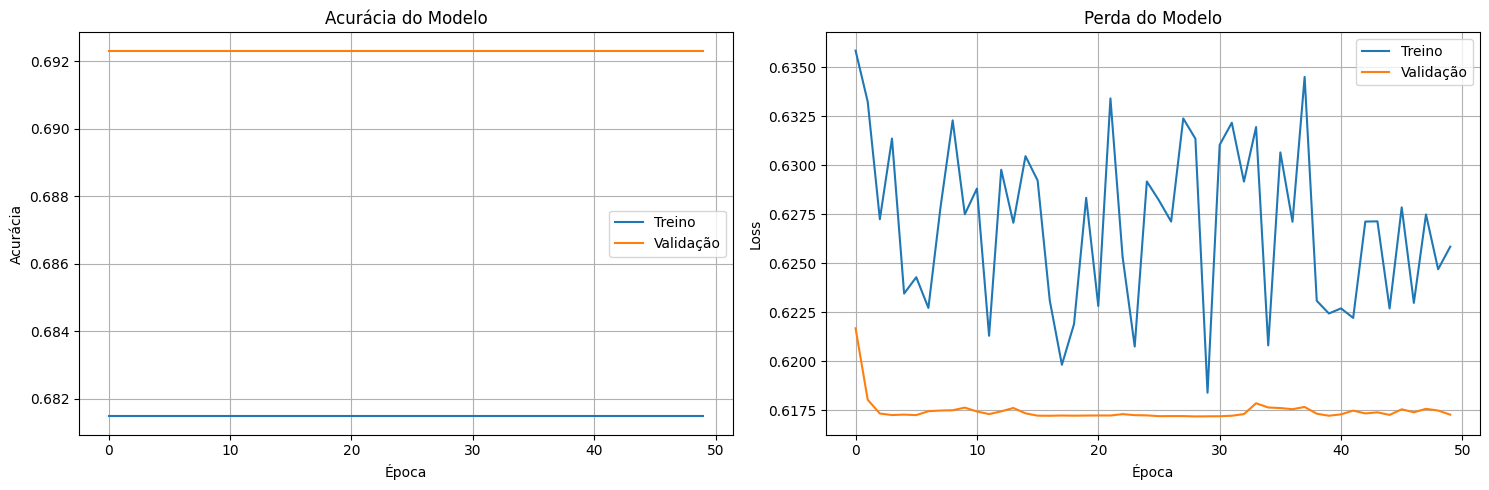

In [8]:
import matplotlib.pyplot as plt

# Criar subplots para acurácia e perda
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Acurácia
ax1.plot(hist.history['accuracy'], label='Treino')
ax1.plot(hist.history['val_accuracy'], label='Validação')
ax1.set_title('Acurácia do Modelo')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.legend()
ax1.grid(True)

# Gráfico de Perda (Loss)
ax2.plot(hist.history['loss'], label='Treino')
ax2.plot(hist.history['val_loss'], label='Validação')
ax2.set_title('Perda do Modelo')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
import time
from sklearn.metrics import accuracy_score

# Carregar os melhores pesos salvos durante o treinamento
model.load_weights('model.weights.best.keras')

# Medir tempo de processamento e realizar predições
start_time = time.time()
y_pred_probs = model.predict(test_dataset)
end_time = time.time()

inference_time = end_time - start_time
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Calcular acurácia
final_accuracy = accuracy_score(test_labels, y_pred)

print(f'Acurácia Final: {final_accuracy:.4f}')
print(f'Tempo de Processamento (Inferência): {inference_time:.2f} segundos')

2/2 ━━━━━━━━━━━━━━━━━━━━ 29s 13s/step
Acurácia Final: 0.6923
Tempo de Processamento (Inferência): 28.61 segundos


Código de agente de monitoramento que fica recebendo imagens e gerando alertas

In [10]:
!pip install crewai
print('CrewAI installed successfully.')
!pip install langchain_google_genai
print('Langchain Google GenAI installed successfully.')

CrewAI installed successfully.
Langchain Google GenAI installed successfully.


Definir uma tool custom que os agentes do CrewAI vão usar. Essa tool vai usar o modelo de Predição do EfficientNet que criamos anteriormente.



In [11]:
from crewai.tools import tool
import cv2
import numpy as np

@tool("flood_detection_tool")
def flood_detection_tool(image_path: str) -> str:
    """ Analisa uma imagem para identificar se tem uma inundação presente usando o modelo EfficientNetB4 treinado anteriormente"""
    try:

        img = cv2.imread(image_path)
        if img is None:
            return f"Error: Could not read the image {image_path}"

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (360, 512))
        img_array = np.expand_dims(img.astype(np.float32) / 255.0, axis=0)

        # Predict
        prediction = model.predict(img_array, verbose=0)[0][0]
        is_flooded = prediction > 0.5

        status = "FLOODING DETECTED" if is_flooded else "No Flooding Detected"
        confidence = prediction if is_flooded else (1 - prediction)

        return f"Analysis Result: {status} (Confidence: {confidence:.2%})"
    except Exception as e:
        return f"Error during analysis: {str(e)}"

print("Flood Detection Tool updated successfully.")

Flood Detection Tool updated successfully.


In [12]:
import os
from crewai.agent import Agent
from crewai import Agent, Task, Crew, Process
from google.colab import userdata


GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

llm_config = {
    'model': 'models/gemini-2.5-flash',
    'llm_type': 'gemini',
    'config': {
        'google_api_key': GOOGLE_API_KEY,
        'temperature': 0.7
    }
}

image_analyst = Agent(
    role='Senior Image Analyst',
    goal='Accurately detect flooding in provided images using specialized computer vision tools.',
    backstory='You are an expert in satellite and aerial imagery analysis. Your primary focus is to identify environmental hazards like flooding to save lives.',
    tools=[flood_detection_tool],
    llm=llm_config,
    allow_delegation=False,
    verbose=True
)

alert_coordinator = Agent(
    role='Emergency Alert Coordinator',
    goal='Evaluate analysis results and determine if a public safety alert is required.',
    backstory='You are responsible for the final decision in the emergency response pipeline. You synthesize technical data into actionable safety warnings.',
    llm=llm_config,
    allow_delegation=True,
    verbose=True
)

print('Monitoring agents (Image Analyst and Alert Coordinator) created successfully.')

Monitoring agents (Image Analyst and Alert Coordinator) created successfully.


In [13]:
from crewai import Task, Crew, Process

# 1. Task for Image Analyst
analyze_image_task = Task(
    description='Using the flood_detection_tool, analyze the image at the path: {image_path}. Determine if flooding is present and provide the confidence level.',
    expected_output='A report stating whether flooding was detected and the confidence percentage.',
    agent=image_analyst
)

# 2. Task for Alert Coordinator
coordinate_alert_task = Task(
    description='Review the report from the Image Analyst. If flooding is detected or if it was not detecedt but the level of confidence is not high enough, draft a public safety alert message. If no flooding is detected, state that no action is needed.',
    expected_output='A final decision on whether to issue an alert, including the alert message text if applicable.',
    agent=alert_coordinator
)

# 3. Define the Crew
monitoring_crew = Crew(
    agents=[image_analyst, alert_coordinator],
    tasks=[analyze_image_task, coordinate_alert_task],
    process=Process.sequential, # Tasks are executed one after the other
)

print('Tasks and monitoring workflow defined successfully.')

Tasks and monitoring workflow defined successfully.


In [15]:
import os
import asyncio

test_images_dir = os.path.join(extract_dir, 'test')
sample_image_name = test_df.iloc[4]['Image ID']
sample_path = os.path.join(test_images_dir, sample_image_name)
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
print(f"--- Starting Simulation for image: {sample_image_name} ---")

async def run_monitoring_crew():
    try:
        await asyncio.wait_for(
            monitoring_crew.kickoff_async(inputs={'image_path': sample_path}),
            timeout=300
        )
    except asyncio.TimeoutError:
        print("Simulation timed out after 300 seconds.")
    except Exception as e:
        print(f"Simulation execution halted: {e}")


# Run the async function
await run_monitoring_crew()

--- Starting Simulation for image: 5006_0.png ---


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Image Analyst                                                                                    │
│                                                                                                                 │
│  Task: Using the flood_detection_tool, analyze the image at the path: louisiana_images/test/5006_0.png.         │
│  Determine if flooding is present and provide the confidence level.                                             │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

ERROR:root:Google Gemini API error: 429 - You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 46.645048911s.
ERROR:crewai.flow.flow:Error executing listener call_llm_native_tools: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 46.645048911s.', 'status':

An unknown error occurred. Please check the details below.
Error details: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 46.645048911s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDime